# Fortgeschrittene - FrozenLake Q-learning

This notebook solves the advanced tasks: Q-learning on deterministic FrozenLake, alpha/gamma comparison, and stochastic FrozenLake with `is_slippery=True`.

The implementation uses epsilon-greedy exploration with epsilon decay because the updated course material discusses the transition from exploration to exploitation over time.

## Dataset Validation
Run this cell to verify that your datasets are present and correctly formatted.

In [1]:
# --- DATASET VALIDATION ---
import os
import pandas as pd

def validate_dataset(filepath, expected_columns=None, avoid_columns=None):
    if not os.path.exists(filepath):
        print(f'❌ ERROR: Dataset not found at {filepath}')
        return False
    try:
        df = pd.read_csv(filepath, nrows=5)
        print(f'✅ SUCCESS: Dataset found at {filepath} (Columns: {df.shape[1]})')
        if expected_columns:
            missing = [c for c in expected_columns if c not in df.columns]
            if missing:
                print(f'⚠️ WARNING: Missing expected columns: {missing}')
                return False
        if avoid_columns:
            forbidden = [c for c in avoid_columns if c in df.columns]
            if forbidden:
                print(f'❌ ERROR: Found forbidden columns {forbidden}. Wrong dataset!')
                return False
        return True
    except Exception as e:
        print(f'❌ ERROR: Could not read dataset: {e}')
        return False

print('Validation helper loaded. Call validate_dataset(path) before loading your data.')
# validate_dataset('../data/your_dataset.csv')

Validation helper loaded. Call validate_dataset(path) before loading your data.


In [2]:
import gymnasium as gym
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product

SEED = 13
np.random.seed(SEED)

In [3]:
def choose_action(q_table, state, epsilon, action_space):
    if np.random.random() < epsilon:
        return action_space.sample()
    return int(np.argmax(q_table[state]))


def train_q_learning(
    is_slippery=False,
    episodes=10_000,
    alpha=0.5,
    gamma=0.9,
    epsilon_start=1.0,
    epsilon_min=0.05,
    epsilon_decay=0.9995,
    seed=SEED
):
    env = gym.make("FrozenLake-v1", is_slippery=is_slippery)
    q_table = np.zeros((env.observation_space.n, env.action_space.n))
    rewards = []
    epsilons = []
    epsilon = epsilon_start

    for episode in range(episodes):
        state, info = env.reset(seed=seed + episode)
        done = False
        total_reward = 0

        while not done:
            action = choose_action(q_table, state, epsilon, env.action_space)
            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            td_target = reward + gamma * np.max(q_table[next_state])
            td_error = td_target - q_table[state, action]
            q_table[state, action] += alpha * td_error

            state = next_state
            total_reward += reward

        epsilon = max(epsilon_min, epsilon * epsilon_decay)
        epsilons.append(epsilon)
        rewards.append(total_reward)

    env.close()
    return q_table, np.array(rewards), np.array(epsilons)

q_det, rewards_det, eps_det = train_q_learning(is_slippery=False, alpha=0.5, gamma=0.9)
rolling_det = pd.Series(rewards_det).rolling(100, min_periods=1).mean()
print("Final mean reward over last 100 episodes:", round(rolling_det.iloc[-1], 3))

Final mean reward over last 100 episodes: 0.94


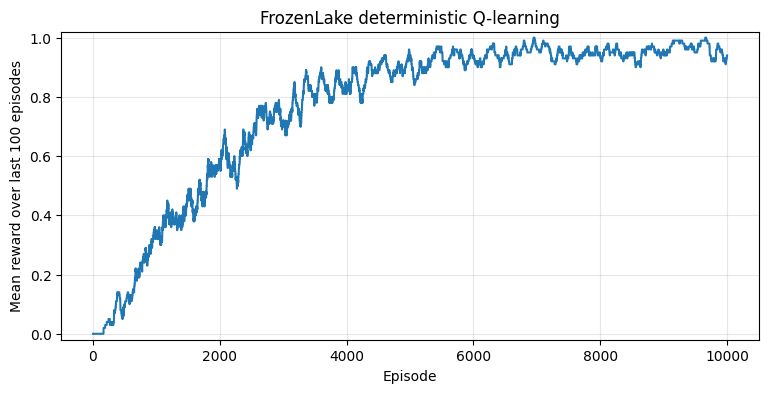

In [4]:
plt.figure(figsize=(9, 4))
plt.plot(rolling_det)
plt.title("FrozenLake deterministic Q-learning")
plt.xlabel("Episode")
plt.ylabel("Mean reward over last 100 episodes")
plt.ylim(-0.02, 1.02)
plt.grid(alpha=0.3)
plt.savefig("../output/frozenlake_deterministic_rolling_reward.png", dpi=160, bbox_inches="tight")
plt.show()

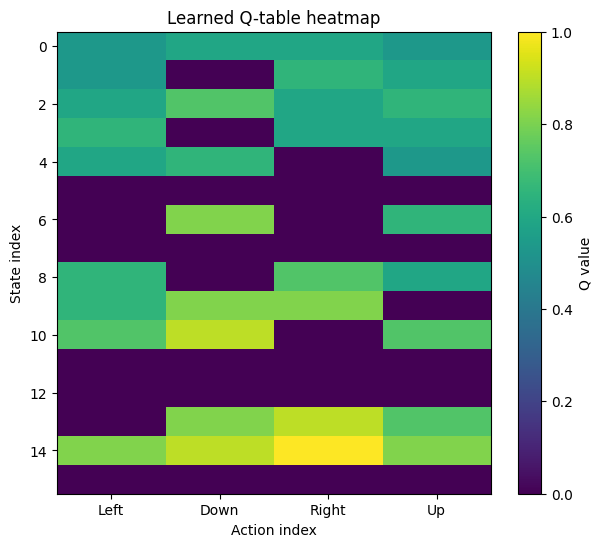

In [5]:
plt.figure(figsize=(7, 6))
plt.imshow(q_det, aspect="auto")
plt.colorbar(label="Q value")
plt.title("Learned Q-table heatmap")
plt.xlabel("Action index")
plt.ylabel("State index")
plt.xticks(range(4), ["Left", "Down", "Right", "Up"])
plt.savefig("../output/frozenlake_q_table_heatmap.png", dpi=160, bbox_inches="tight")
plt.show()

In [6]:
def convergence_episode(rewards, window=100, threshold=0.80):
    rolling = pd.Series(rewards).rolling(window, min_periods=window).mean()
    hits = np.where(rolling >= threshold)[0]
    return int(hits[0] + 1) if len(hits) else None

results = []
for alpha, gamma in product([0.1, 0.5, 0.9], [0.7, 0.9, 0.99]):
    q_table, rewards, epsilons = train_q_learning(
        is_slippery=False,
        episodes=10_000,
        alpha=alpha,
        gamma=gamma
    )
    results.append({
        "alpha": alpha,
        "gamma": gamma,
        "final_mean_100": pd.Series(rewards).rolling(100).mean().iloc[-1],
        "convergence_episode": convergence_episode(rewards)
    })

results_df = pd.DataFrame(results).sort_values("convergence_episode", na_position="last")
results_df

,alpha,gamma,final_mean_100,convergence_episode
1,0.1,0.90,0.93,2763
4,0.5,0.90,0.95,2862
8,0.9,0.99,0.97,2869
6,0.9,0.70,0.97,2958
5,0.5,0.99,0.98,2975
0,0.1,0.70,0.96,3029
7,0.9,0.90,0.94,3094
3,0.5,0.70,0.95,3099
2,0.1,0.99,0.94,3202


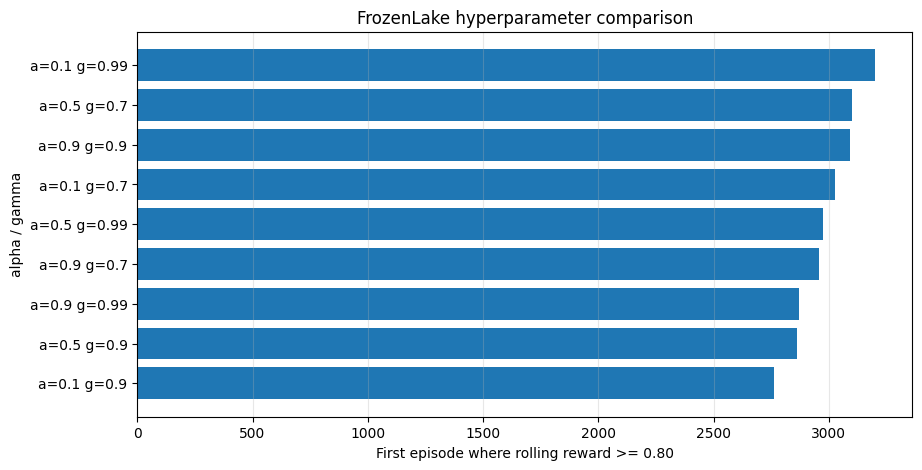

In [7]:
plot_df = results_df.copy()
plot_df["setting"] = plot_df.apply(lambda row: f"a={row['alpha']} g={row['gamma']}", axis=1)
plt.figure(figsize=(10, 5))
plt.barh(plot_df["setting"], plot_df["convergence_episode"])
plt.title("FrozenLake hyperparameter comparison")
plt.xlabel("First episode where rolling reward >= 0.80")
plt.ylabel("alpha / gamma")
plt.grid(axis="x", alpha=0.3)
plt.savefig("../output/frozenlake_hyperparameter_convergence.png", dpi=160, bbox_inches="tight")
plt.show()

In [8]:
q_slip_low, rewards_slip_low, eps_low = train_q_learning(
    is_slippery=True,
    episodes=10_000,
    alpha=0.1,
    gamma=0.99,
    epsilon_decay=0.9995
)
q_slip_high, rewards_slip_high, eps_high = train_q_learning(
    is_slippery=True,
    episodes=10_000,
    alpha=0.5,
    gamma=0.99,
    epsilon_decay=0.9995
)

slip_low_roll = pd.Series(rewards_slip_low).rolling(100, min_periods=1).mean()
slip_high_roll = pd.Series(rewards_slip_high).rolling(100, min_periods=1).mean()
print("Low alpha final mean reward:", round(slip_low_roll.iloc[-1], 3))
print("Higher alpha final mean reward:", round(slip_high_roll.iloc[-1], 3))

Low alpha final mean reward: 0.49
Higher alpha final mean reward: 0.35


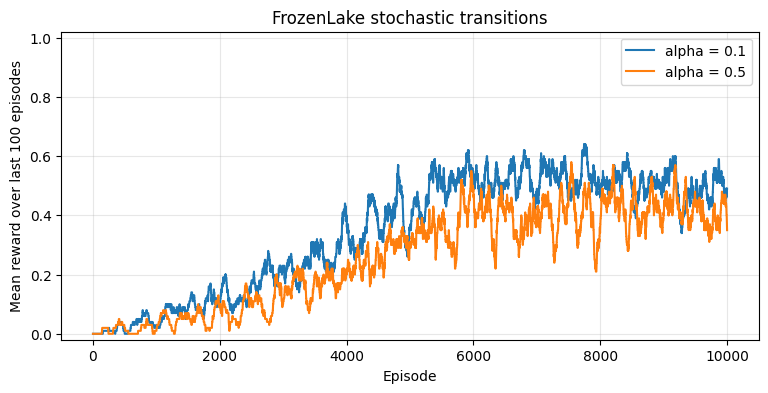

In [9]:
plt.figure(figsize=(9, 4))
plt.plot(slip_low_roll, label="alpha = 0.1")
plt.plot(slip_high_roll, label="alpha = 0.5")
plt.title("FrozenLake stochastic transitions")
plt.xlabel("Episode")
plt.ylabel("Mean reward over last 100 episodes")
plt.ylim(-0.02, 1.02)
plt.grid(alpha=0.3)
plt.legend()
plt.savefig("../output/frozenlake_slippery_alpha_comparison.png", dpi=160, bbox_inches="tight")
plt.show()

## Advanced conclusion

In the deterministic environment, Q-learning converges because actions reliably lead to the intended next state. With `is_slippery=True`, the transition model becomes stochastic: the same action can lead to different next states. A lower learning rate is often more stable because one random transition does not overwrite the Q-table too strongly.

Epsilon decay is used to start with exploration and then gradually move toward exploitation of the learned Q-values.